In [1]:
# import dependencies
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from shapely.geometry import Polygon, MultiPolygon

### Data Cleaning & Spatial Aggregation Summary

- Loaded FEMA National Risk Index (NRI) tract-level shapefile and Vermont census town boundaries.
- Reprojected all spatial data to an equal-area CRS (EPSG:5070) for accurate area calculations, then to WGS84 (EPSG:4326) for web mapping.
- Performed a spatial intersection between NRI tracts and towns to allocate tract-level risk and loss variables to towns using area-weighted fractions.
- Filtered out sliver overlaps (<1% of tract area) and renormalized weights so each tract’s contributions sum to 1.
- Calculated area-weighted sums for raw variables (e.g., expected annual loss, population, building/agricultural value) and area-weighted averages for normalized indices (e.g., RISK_SCORE, SOVI_SCORE, RESL_SCORE, CRF_VALUE) at the town level.
- Computed per capita, per building value, and per agricultural value expected annual loss metrics for each town.
- Validated aggregation by comparing statewide tract-level totals to the sum of town-level aggregates and inspecting results for major towns.
- Visualized tract-level and town-level expected annual loss (IFLD_EALT) side-by-side using choropleth maps.
- Exported final town-level NRI summary as CSV and tract-level NRI as GeoJSON for downstream analysis and web mapping.

In [2]:
# ignore this step; I needed to use the shapefile to join census tracts to towns
# the shpaefile has the same data as the csv, but with geometry

# # open fema nri data
# nri = pd.read_csv("../data/raw/FEMA_NRI/NRI_Table_censusTracts.csv")
# # extract only vermont data
# nri_vt = nri[nri["STATE"] == "Vermont"]
# len(nri_vt)
# # save to csv
# nri_vt.to_csv("../data/raw/FEMA_NRI/nri_vt.csv", index=False)

# open vt fema nri data
# nri_vt = pd.read_csv("../data/raw/FEMA_NRI/nri_vt.csv")
# nri_vt.columns

In [3]:
# open shapefile
fp = "../data/raw/census_shp/tl_2025_50_cousub.shp"
gdf_census = gpd.read_file(fp)

# prune to only include relevant columns
gdf_census = gdf_census[["GEOID", "NAME", "NAMELSAD", "ALAND", "AWATER", "geometry"]]

# # rename columns for clarity
# gdf_census = gdf_census.rename(columns={"NAMELSAD": "town_name"})
# print(gdf_census.columns)

# convert to equal-area CRS for accurate area calculations
gdf_census = gdf_census.to_crs("EPSG:5070")

# check projection
print(gdf_census.crs)

EPSG:5070


In [4]:
# open fema nri shapefile
nri_gdf = gpd.read_file(
    "../data/raw/FEMA_NRI/NRI_Shapefile_CensusTracts/NRI_Shapefile_CensusTracts.shp"
)
nri_vt_gdf = nri_gdf[nri_gdf["STATE"] == "Vermont"]
len(nri_vt_gdf)

193

In [5]:
# ensure both GeoDataFrames are in EPSG:4326
nri_vt_gdf = nri_vt_gdf.to_crs(epsg=4326)
gdf_census = gdf_census.to_crs(epsg=4326)

# Plotly choropleths disabled so code shows on GitHub
# Matplotlib version below

# # Create subplot figure
# fig = make_subplots(
#     rows=1,
#     cols=2,
#     subplot_titles=("NRI by Census Tract with Town Boundaries", "NRI Risk Scores Only"),
#     specs=[[{"type": "mapbox"}, {"type": "mapbox"}]],
# )

# # Left: NRI risk scores with town boundaries
# choropleth1 = px.choropleth_mapbox(
#     nri_vt_gdf,
#     geojson=nri_vt_gdf.geometry.__geo_interface__,
#     locations=nri_vt_gdf.index,
#     color="RISK_SCORE",
#     color_continuous_scale="Blues",
#     opacity=0.7,
# )
# for trace in choropleth1.data:
#     fig.add_trace(trace, row=1, col=1)

# # Add census boundaries as lines
# for _, row in gdf_census.iterrows():
#     geom = row.geometry
#     if isinstance(geom, Polygon):
#         x, y = geom.exterior.xy
#         fig.add_trace(
#             go.Scattermapbox(
#                 lon=list(x),
#                 lat=list(y),
#                 mode="lines",
#                 line=dict(color="gray", width=1),
#                 showlegend=False,
#                 hoverinfo="skip",
#             ),
#             row=1,
#             col=1,
#         )
#     elif isinstance(geom, MultiPolygon):
#         for poly in geom.geoms:
#             x, y = poly.exterior.xy
#             fig.add_trace(
#                 go.Scattermapbox(
#                     lon=list(x),
#                     lat=list(y),
#                     mode="lines",
#                     line=dict(color="gray", width=1),
#                     showlegend=False,
#                     hoverinfo="skip",
#                 ),
#                 row=1,
#                 col=1,
#             )

# # Right: NRI risk scores only
# choropleth2 = px.choropleth_mapbox(
#     nri_vt_gdf,
#     geojson=nri_vt_gdf.geometry.__geo_interface__,
#     locations=nri_vt_gdf.index,
#     color="RISK_SCORE",
#     color_continuous_scale="Reds",
#     opacity=0.7,
# )
# for trace in choropleth2.data:
#     fig.add_trace(trace, row=1, col=2)

# # Mapbox settings
# center = dict(
#     lat=nri_vt_gdf.geometry.centroid.y.mean(), lon=nri_vt_gdf.geometry.centroid.x.mean()
# )
# fig.update_layout(
#     mapbox1=dict(style="carto-positron", zoom=7, center=center),
#     mapbox2=dict(style="carto-positron", zoom=7, center=center),
#     margin={"r": 0, "t": 40, "l": 0, "b": 0},
#     height=600,
# )

# fig.show()

In [6]:
# ensure both GeoDataFrames are in EPSG:5070, an equal-area projection suitable for area calculations

# convert to equal-area CRS for accurate area calculations
nri_vt_gdf = nri_vt_gdf.to_crs("EPSG:5070")

# check projection
print(f"NRI projection after conversion: {nri_vt_gdf.crs}")

# convert to equal-area CRS for accurate area calculations
gdf_census = gdf_census.to_crs("EPSG:5070")

# check projection
print(f"Census projection after conversion: {gdf_census.crs}")

NRI projection after conversion: EPSG:5070
Census projection after conversion: EPSG:5070


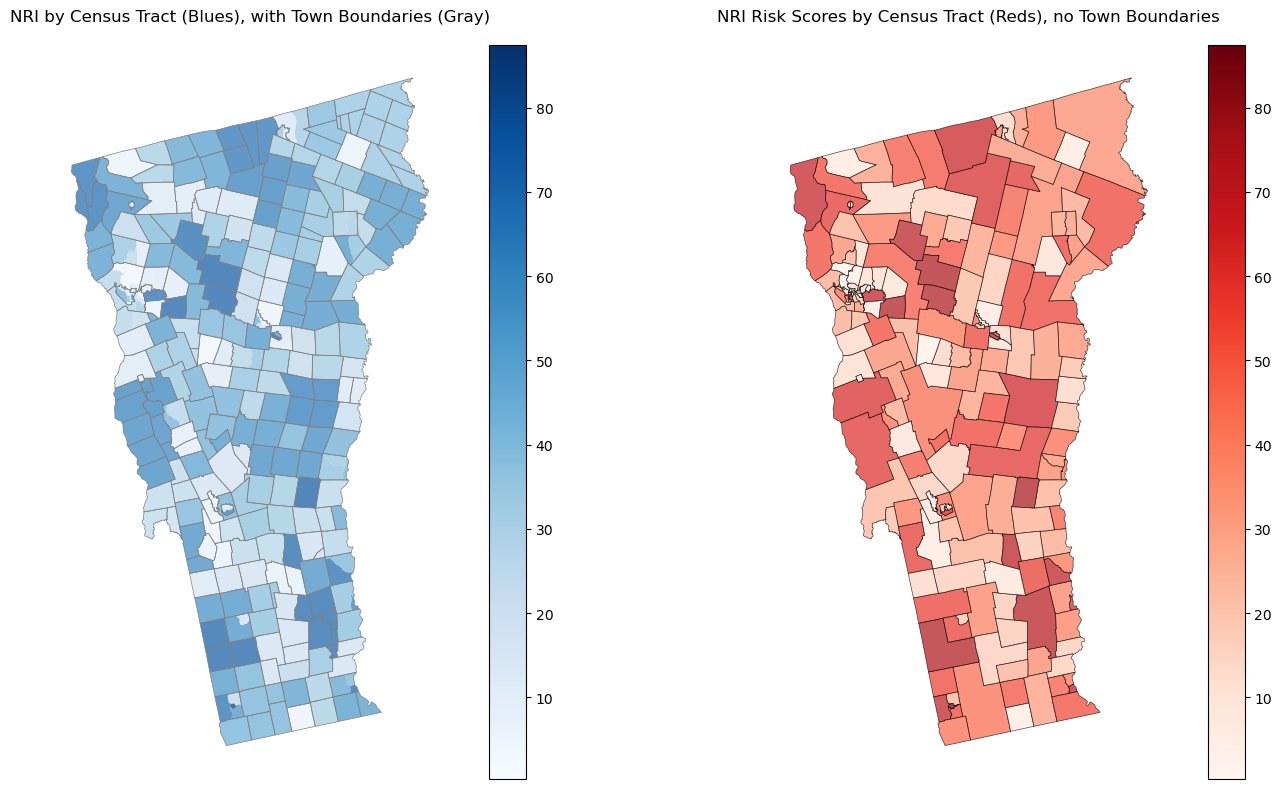

In [7]:
# Create side-by-side plots using Matplotlib
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 8))

# Left: NRI risk scores over town boundaries (Blues)
gdf_census.boundary.plot(ax=axes[0], color="gray", linewidth=0.5)
nri_vt_gdf.plot(ax=axes[0], column="RISK_SCORE", cmap="Blues", legend=True, alpha=0.7)
axes[0].set_title("NRI by Census Tract (Blues), with Town Boundaries (Gray)")
axes[0].set_axis_off()

# Right: NRI risk scores only (Reds)
nri_vt_gdf.plot(
    ax=axes[1],
    column="RISK_SCORE",
    cmap="Reds",
    legend=True,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.5,
)
axes[1].set_title("NRI Risk Scores by Census Tract (Reds), no Town Boundaries")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

In [8]:
# overlay FEMA NRI on town boundaries
# creates town-tract fragments, to be re-aggregated to town level later
intersected = gpd.overlay(gdf_census, nri_vt_gdf, how="intersection")

In [9]:
# calculate area of intersection (each town-tract fragment)
intersected["area_intersect"] = intersected.geometry.area

# total area of each tract
# caluclate the original area of each tract (before intersection)
# TRACTFIPS is the unique identifier for each census tract
tract_areas = nri_vt_gdf[["TRACTFIPS", "geometry"]].copy()
tract_areas["area_tract"] = tract_areas.geometry.area

# merge back
# so each town-tract fragment has both the area of the fragment and the total area of the original tract
intersected = intersected.merge(
    tract_areas[["TRACTFIPS", "area_tract"]], on="TRACTFIPS", how="left"
)

# weight = % of tract in town
# town-tract fragment area / total tract area
intersected["weight"] = intersected["area_intersect"] / intersected["area_tract"]

# filter out very small overlaps, slivers toeing over boundaries
# (e.g., when a border is double counted for both towns - GIS artifacts)
intersected = intersected[intersected["weight"] > 0.01]

# post-filtering, normalize weights so they sum to 1 for each tract
# re-scale weights so each tract still contriutes 100% of its original value (no 99.73% nonsense)
weights_sum = intersected.groupby("TRACTFIPS")["weight"].transform("sum")
intersected["weight"] = intersected["weight"] / weights_sum

# check if weights match towns (they won't - some tracts are split across multiple towns, some towns contain multiple tracts)
intersected["weight"].describe()

count    307.000000
mean       0.628664
std        0.353486
min        0.020401
25%        0.293996
50%        0.523666
75%        1.000000
max        1.000000
Name: weight, dtype: float64

In [10]:
# check that most tracts are accounted for after filtering slivers
# sums should be 1 after re-normalization
intersected.groupby("TRACTFIPS")["weight"].sum().describe()

count    1.930000e+02
mean     1.000000e+00
std      1.791615e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: weight, dtype: float64

In [11]:
# check sum of weights per town (again, they won't match- some tracts are split across multiple towns, some towns contain multiple tracts)
# GEOID is the census identifier for each town, NAMELSAD is the town name
weight_sums = intersected.groupby(["GEOID", "NAMELSAD"])["weight"].sum().reset_index()
print("Sum of weights per town (1 = tract matches town, <1 = tract partially covers town, >1 = multiple tracts cover town):")
print(weight_sums["weight"].describe())
display(weight_sums.head())

Sum of weights per town (1 = tract matches town, <1 = tract partially covers town, >1 = multiple tracts cover town):
count    255.000000
mean       0.756863
std        1.000395
min        0.028277
25%        0.261974
50%        0.490629
75%        1.000000
max       11.000000
Name: weight, dtype: float64


,GEOID,NAMELSAD,weight
0,5000100325,Addison town,0.351583
1,5000108575,Bridport town,0.250671
2,5000109025,Bristol town,1.000000
3,5000116000,Cornwall town,0.155672
4,5000126300,Ferrisburgh town,1.000000


In [12]:
# apply weighting to NRI variables and aggregate by town

# Important limitation:
#
# Area-weighted interpolation assumes tract-level variables are
# distributed uniformly within each tract. In reality, population,
# assets, and flood risk are often spatially concentrated.
#
# This is a practical approximation given the available data and the
# generally close alignment between Vermont town and tract boundaries,
# but the resulting town-level estimates should be interpreted as
# estimates rather than exact measurements.

nri_vars = [
    "RISK_SCORE",  # National Risk Index score, normalized 0-100
    "SOVI_SCORE",  # Social Vulnerability Index score, normalized 0-100
    "IFLD_RISKS",  # flood risk score, normalized 0-100
    "IFLD_EALT",  # expected annual loss from flooding, in dollars
    "IFLD_EALP",  # expected annual loss in population from flooding (fatalities and injuries, injuries 1/10th of a fatality)
    "IFLD_EALPE",  # expected annual loss in population, in equivalent dollars
    "IFLD_EALB",  # expected annual loss to buildings from flooding
    "IFLD_EALA",  # expected annual loss to agriculture from flooding
    # "EAL_VALT", # total expected annual loss
    # "EAL_VALB", # expected annual loss to buildings
    # "EAL_VALP", # expected annual loss to population
    # "EAL_VALA", # expected annual loss to agriculture
    "RESL_SCORE",  # resilience score, normalized 0-100
    "CRF_VALUE",  # Community Risk Factor score, normalized 0-100
    "POPULATION",  # population of tract
    "BUILDVALUE",  # total building value in tract, in dollars
    "AGRIVALUE",  # total agricultural value in tract, in dollars
    "AREA",  # area of tract in square miles
]

# apply weights to each value and town-tract fragment
for col in nri_vars:
    intersected[f"{col}_weighted"] = intersected[col] * intersected["weight"]

# aggregate town-tract fragments by town
# GEOID is the census identifier for each town, NAMELSAD is the town name, ALAND is the land area of the town in square meters (from census data)
town_nri = (
    intersected.groupby(["GEOID", "NAMELSAD", "ALAND"])[
        [f"{col}_weighted" for col in nri_vars]
    ]
    .sum()
    .reset_index()
)

# calculate area in square miles to compare with NRI tract AREA_weighted
town_nri["ALAND_sqmi"] = town_nri["ALAND"] / 2_589_988.110336
town_nri.drop(columns=["ALAND"], inplace=True)

# derived metrics
# lazy - potential divide by zero
# Expected Annual Loss (EAL) per capita
town_nri["EAL_per_capita"] = (
    town_nri["IFLD_EALT_weighted"] / town_nri["POPULATION_weighted"]
)

# EAL per building value
town_nri["EAL_per_building_value"] = (
    town_nri["IFLD_EALT_weighted"] / town_nri["BUILDVALUE_weighted"]
)

# EAL per agricultural value
town_nri["EAL_per_agricultural_value"] = (
    town_nri["IFLD_EALT_weighted"] / town_nri["AGRIVALUE_weighted"]
)

# merge in the weights for each town
town_nri = town_nri.merge(
    weight_sums[["GEOID", "NAMELSAD", "weight"]],
    on=["GEOID", "NAMELSAD"],
    how="left",
    suffixes=("", "_sum"),
)

# average area-weighted scores (for normalized variables)
# variables that can't be summed
for col in ["RISK_SCORE", "SOVI_SCORE", "IFLD_RISKS", "RESL_SCORE", "CRF_VALUE"]:
    weighted_col = f"{col}_weighted"
    town_nri[f"{col}_avg"] = town_nri[weighted_col] / town_nri["weight"]
    town_nri.drop(columns=[weighted_col], inplace=True)

# Validation:
# Population totals are broadly consistent with ACS town populations,
# and weighted tract area is broadly consistent with census town area.
# The tract-to-town allocation looks like it's working.

town_nri.head()

,GEOID,NAMELSAD,IFLD_EALT_weighted,IFLD_EALP_weighted,IFLD_EALPE_weighted,IFLD_EALB_weighted,IFLD_EALA_weighted,POPULATION_weighted,BUILDVALUE_weighted,AGRIVALUE_weighted,...,ALAND_sqmi,EAL_per_capita,EAL_per_building_value,EAL_per_agricultural_value,weight,RISK_SCORE_avg,SOVI_SCORE_avg,IFLD_RISKS_avg,RESL_SCORE_avg,CRF_VALUE_avg
0,5000100325,Addison town,442982.271717,0.000115,1575.962146,437428.465870,3977.843699,1741.741558,6.779501e+08,2.321149e+07,...,41.587203,254.332952,0.000653,0.019085,0.351583,62.333369,43.245276,83.239984,73.792205,1.068012
1,5000108575,Bridport town,248277.646949,0.000062,850.354565,244570.508715,2856.783668,1337.328973,4.317563e+08,2.239337e+07,...,43.690886,185.651887,0.000575,0.011087,0.250671,60.297528,53.229876,77.165757,73.792205,1.148067
2,5000109025,Bristol town,801320.926477,0.000358,4898.598128,795192.604600,1229.723749,3782.000000,9.091027e+08,5.316545e+06,...,40.547707,211.877559,0.000881,0.150722,1.000000,35.964944,41.897175,63.967274,73.792205,1.057773
3,5000116000,Cornwall town,154186.101522,0.000039,528.089649,151883.883827,1774.128046,830.511902,2.681305e+08,1.390679e+07,...,28.567997,185.651887,0.000575,0.011087,0.155672,60.297528,53.229876,77.165757,73.792205,1.148067
4,5000126300,Ferrisburgh town,655683.709121,0.000173,2376.763423,650788.081400,2518.864298,2646.000000,8.613900e+08,2.304609e+07,...,47.483430,247.801855,0.000761,0.028451,1.000000,13.920303,9.209856,34.050397,73.792205,0.724110


In [13]:
# check number of towns
# (lost one, due to filtering slivers - it's Warner's Grant, population 0)
len(town_nri)

255

In [14]:
# inspect weights and results for major population center in the state
# (Burlington and surrounding towns), where towns contain multiple tracts
selected_towns = [
    "Burlington city",
    "Winooski city",
    "Colchester town",
    "Essex town",
    "Essex Junction city",
    "South Burlington city",
]

print("--- Sum of weights for selected towns ---")
display(weight_sums[weight_sums["NAMELSAD"].isin(selected_towns)])

print("--- Aggregated and normalized NRI values for selected towns ---")
display(town_nri[town_nri["NAMELSAD"].isin(selected_towns)])

--- Sum of weights for selected towns ---


,GEOID,NAMELSAD,weight
59,5000710675,Burlington city,11.000000
61,5000714875,Colchester town,5.020401
62,5000724175,Essex town,2.000000
63,5000724400,Essex Junction city,2.000000
71,5000766175,South Burlington city,5.000000
75,5000785150,Winooski city,2.979599


--- Aggregated and normalized NRI values for selected towns ---


,GEOID,NAMELSAD,IFLD_EALT_weighted,IFLD_EALP_weighted,IFLD_EALPE_weighted,IFLD_EALB_weighted,IFLD_EALA_weighted,POPULATION_weighted,BUILDVALUE_weighted,AGRIVALUE_weighted,...,ALAND_sqmi,EAL_per_capita,EAL_per_building_value,EAL_per_agricultural_value,weight,RISK_SCORE_avg,SOVI_SCORE_avg,IFLD_RISKS_avg,RESL_SCORE_avg,CRF_VALUE_avg
59,5000710675,Burlington city,6.560160e+06,0.001178,16133.599942,6.541523e+06,2502.961707,44723.000000,9.236105e+09,6.543230e+05,...,10.302962,146.684249,0.000710,10.025874,11.000000,23.553036,39.875830,44.540730,91.112427,1.037866
61,5000714875,Colchester town,2.186657e+06,0.001492,20443.717039,2.156316e+06,9897.868404,17555.330168,4.186124e+09,4.693508e+06,...,36.309130,124.558020,0.000522,0.465890,5.020401,11.287346,24.377254,23.845500,91.112427,0.883872
62,5000724175,Essex town,1.323935e+06,0.000781,10696.413620,1.295926e+06,17312.833484,11482.000000,2.416433e+09,6.461614e+06,...,34.340673,115.305267,0.000548,0.204892,2.000000,12.746602,9.209856,29.049980,91.112427,0.643043
63,5000724400,Essex Junction city,1.177695e+06,0.000697,9543.718651,1.166720e+06,1430.377800,10612.000000,1.647557e+09,7.430050e+05,...,4.569080,110.977624,0.000715,1.585043,2.000000,9.403874,9.209856,24.109022,91.112427,0.643043
71,5000766175,South Burlington city,3.194753e+06,0.001732,23724.314023,3.166743e+06,4286.091828,20258.000000,6.097112e+09,2.890125e+06,...,16.434533,157.703283,0.000524,1.105403,5.000000,21.142545,13.742344,39.310287,91.112427,0.761310
75,5000785150,Winooski city,1.495390e+06,0.000785,10750.120098,1.484640e+06,0.000000,7965.669832,1.165359e+09,4.089803e+02,...,1.380888,187.729405,0.001283,3656.387442,2.979599,7.997983,20.014640,25.731182,91.112427,0.832279


In [15]:
print(town_nri.weight.describe())
print(town_nri.RISK_SCORE_avg.describe())
print(town_nri.SOVI_SCORE_avg.describe())

count    255.000000
mean       0.756863
std        1.000395
min        0.028277
25%        0.261974
50%        0.490629
75%        1.000000
max       11.000000
Name: weight, dtype: float64
count    255.000000
mean      39.952008
std       18.512869
min        4.248867
25%       25.315425
50%       38.757090
75%       56.046282
max       75.792278
Name: RISK_SCORE_avg, dtype: float64
count    255.000000
mean      39.918622
std       18.087595
min        9.209856
25%       27.088195
50%       38.449920
75%       54.123082
max       78.135699
Name: SOVI_SCORE_avg, dtype: float64


In [16]:
# Validation:
# Area-weighted interpolation should preserve statewide totals.
# Because tract weights were re-normalized after sliver removal,
# the sum of town-level allocations should closely match the original tract-level totals.

# sum expected annual loss and population for all VT tracts
statewide_eal = nri_vt_gdf["IFLD_EALT"].sum()
statewide_pop = nri_vt_gdf["POPULATION"].sum()
print("Statewide tract total EAL:", statewide_eal)
print("Statewide tract total population:", statewide_pop)

# sum the area-weighted (or population-weighted) values across all towns
town_eal = town_nri["IFLD_EALT_weighted"].sum()
town_pop = town_nri["POPULATION_weighted"].sum()
print("Sum of town-level EAL:", town_eal)
print("Sum of town-level population:", town_pop)

Statewide tract total EAL: 162495846.433005
Statewide tract total population: 642541
Sum of town-level EAL: 162495846.43300503
Sum of town-level population: 642541.0


In [17]:
# choropleths of tract-level IFLD_EALT and town-level area-weighted IFLD_EALT

# ensure both GeoDataFrames are in EPSG:4326 for plotting
nri_vt_gdf = nri_vt_gdf.to_crs(epsg=4326)
gdf_census = gdf_census.to_crs(epsg=4326)

# Plotly chorpleths disabled so code shows on GitHub
# Matplotlib version below

# # Left: Tract-level IFLD_EALT
# fig1 = px.choropleth_mapbox(
#     nri_vt_gdf,
#     geojson=nri_vt_gdf.geometry.__geo_interface__,
#     locations=nri_vt_gdf.index,
#     color="IFLD_EALT",
#     color_continuous_scale="Blues",
#     mapbox_style="carto-positron",
#     zoom=7,
#     center={
#         "lat": nri_vt_gdf.geometry.centroid.y.mean(),
#         "lon": nri_vt_gdf.geometry.centroid.x.mean(),
#     },
#     opacity=0.7,
#     title="Tract-level IFLD_EALT",
# )

# # Right: Town-level area-weighted IFLD_EALT
# fig2 = px.choropleth_mapbox(
#     town_nri,
#     geojson=gdf_census.set_index("GEOID").geometry.__geo_interface__,
#     locations="GEOID",
#     color="IFLD_EALT_weighted",
#     color_continuous_scale="Reds",
#     mapbox_style="carto-positron",
#     zoom=7,
#     center={
#         "lat": gdf_census.geometry.centroid.y.mean(),
#         "lon": gdf_census.geometry.centroid.x.mean(),
#     },
#     opacity=0.7,
#     title="Town-level Area-weighted IFLD_EALT",
# )

# # Combine into side-by-side subplots
# fig = make_subplots(
#     rows=1,
#     cols=2,
#     subplot_titles=("Tract-level IFLD_EALT", "Town-level Area-weighted IFLD_EALT"),
#     specs=[[{"type": "mapbox"}, {"type": "mapbox"}]],
# )

# for trace in fig1.data:
#     fig.add_trace(trace, row=1, col=1)
# for trace in fig2.data:
#     fig.add_trace(trace, row=1, col=2)

# center = {
#     "lat": nri_vt_gdf.geometry.centroid.y.mean(),
#     "lon": nri_vt_gdf.geometry.centroid.x.mean(),
# }
# fig.update_layout(
#     mapbox1=dict(style="carto-positron", zoom=7, center=center),
#     mapbox2=dict(style="carto-positron", zoom=7, center=center),
#     margin={"r": 0, "t": 40, "l": 0, "b": 0},
#     height=600,
# )

# fig.show()

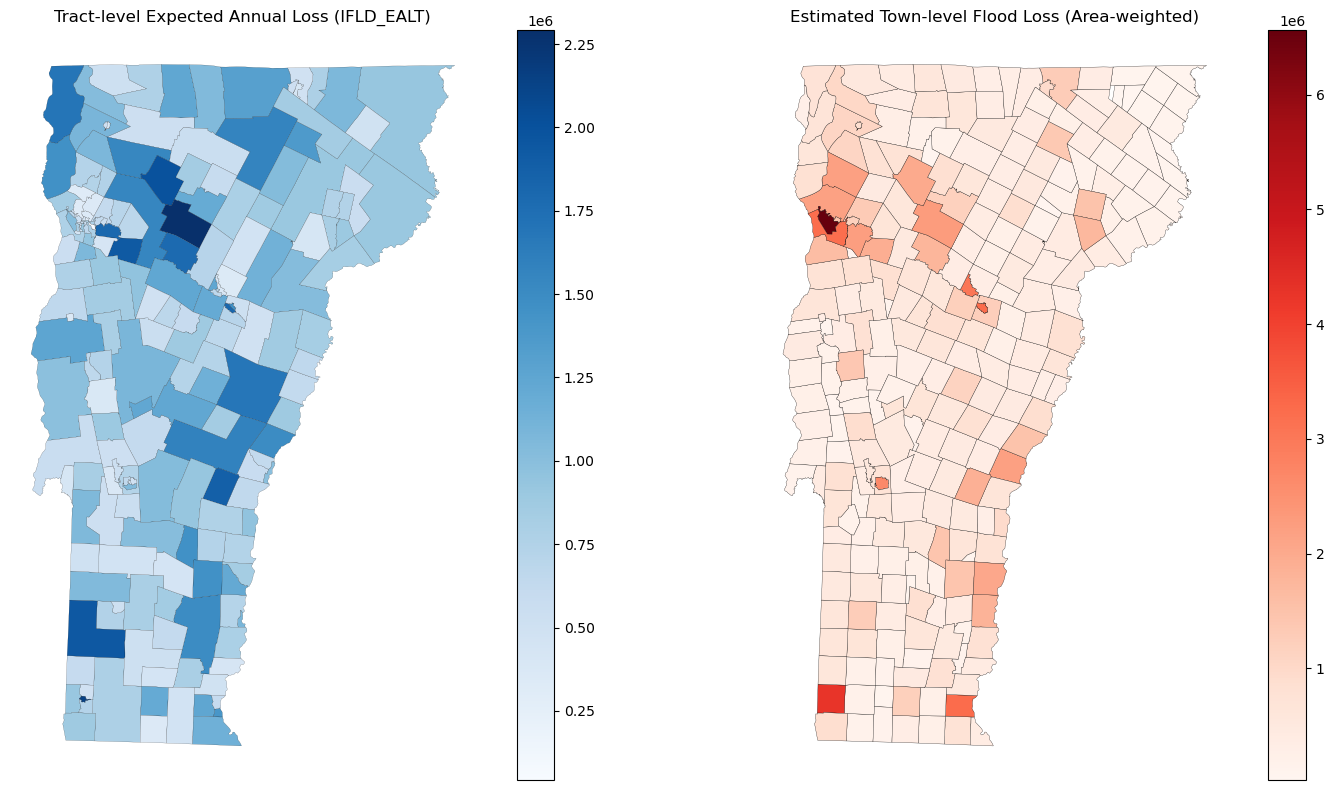

In [18]:
# Attach town-level NRI results back to town geometries for mapping
town_map = gdf_census.merge(
    town_nri,
    on="GEOID",
    how="left"
)

# Compare original tract-level flood losses with the town-level
# estimates produced by the area-weighted interpolation.

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 8)
)

# Left: Tract-level IFLD_EALT
nri_vt_gdf.plot(
    ax=axes[0],
    column="IFLD_EALT",
    cmap="Blues",
    legend=True,
    linewidth=0.1,
    edgecolor="black"
)

axes[0].set_title("Tract-level Expected Annual Loss (IFLD_EALT)")
axes[0].set_axis_off()

# Right: Town-level area-weighted IFLD_EALT
town_map.plot(
    ax=axes[1],
    column="IFLD_EALT_weighted",
    cmap="Reds",
    legend=True,
    linewidth=0.2,
    edgecolor="black"
)

axes[1].set_title("Estimated Town-level Flood Loss (Area-weighted)")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

In [19]:
# Show unique resilience scores by county
# proves resilience scores are calculated at the county level
# irrelevant for this analysis, but interesting
print(nri_vt_gdf.groupby("COUNTY")["RESL_SCORE"].unique())

COUNTY
Addison       [73.7922047151]
Bennington    [61.0757019311]
Caledonia     [58.5286103542]
Chittenden    [91.1124274375]
Essex         [29.5344153536]
Franklin      [86.2018718161]
Grand Isle    [99.3057694586]
Lamoille      [74.2269873238]
Orange        [46.3902381234]
Orleans        [71.820874304]
Rutland       [69.2311337519]
Washington    [90.4276744462]
Windham        [65.340599455]
Windsor       [60.9027366426]
Name: RESL_SCORE, dtype: object


In [20]:
# rename NAMESLAD to town_name for merging with census data
town_nri = town_nri.rename(columns={"NAMELSAD": "town_name"})

In [21]:
# export town-level NRI to csv
town_nri.to_csv("../data/cleaned/fema_nri_town_level.csv", index=False)

In [22]:
# save tract-level NRI as geojson for web mapping

# ensure geometries are in WGS84 (EPSG:4326) for web mapping
nri_vt_gdf = nri_vt_gdf.to_crs(epsg=4326)

# simplify geometries to reduce file size (tolerance is in degrees, so this is roughly 50m - adjust as needed)
# didn't do it - the file size was manageable
# nri_vt_gdf["geometry"] = nri_vt_gdf.geometry.simplify(0.0005)

keep_cols = [
    "TRACTFIPS",
    "RISK_SCORE",
    "SOVI_SCORE",
    "IFLD_RISKS",
    "IFLD_EALT",
    "geometry",
]

nri_vt_gdf[keep_cols].to_file("../data/cleaned/nri_tracts.geojson", driver="GeoJSON")

In [23]:
# calculate spearman correlation between  NRI risk scores and SOVI scores at the tract level
# out of curiosity, to understand risk score 
from scipy.stats import spearmanr
corr, p_value = spearmanr(nri_vt_gdf["RISK_SCORE"], nri_vt_gdf["SOVI_SCORE"])
print(f"Spearman correlation between NRI risk scores and SOVI scores: {corr:.4f} (p-value: {p_value:.4e})")
# calculate spearman correlation between  NRI risk scores and EALT at the tract level
corr_ealt, p_value_ealt = spearmanr(nri_vt_gdf["RISK_SCORE"], nri_vt_gdf["IFLD_EALT"])
print(f"Spearman correlation between NRI risk scores and IFLD_EALT: {corr_ealt:.4f} (p-value: {p_value_ealt:.4e})")
# spearman correlation between SOVI scores and EALT at the tract level
corr_sovi_ealt, p_value_sovi_ealt = spearmanr(nri_vt_gdf["SOVI_SCORE"], nri_vt_gdf["IFLD_EALT"])
print(f"Spearman correlation between SOVI scores and IFLD_EALT: {corr_sovi_ealt:.4f} (p-value: {p_value_sovi_ealt:.4e})")
# spearmanr of risk score and population
corr_pop, p_value_pop = spearmanr(nri_vt_gdf["RISK_SCORE"], nri_vt_gdf["POPULATION"])
print(f"Spearman correlation between NRI risk scores and population: {corr_pop:.4f} (p-value: {p_value_pop:.4e})")
# spearmanr of risk score and building value
corr_buildvalue, p_value_buildvalue = spearmanr(nri_vt_gdf["RISK_SCORE"], nri_vt_gdf["BUILDVALUE"])
print(f"Spearman correlation between NRI risk scores and building value: {corr_buildvalue:.4f} (p-value: {p_value_buildvalue:.4e})")
# spearmanr of risk score and agricultural value
corr_agrivalue, p_value_agrivalue = spearmanr(nri_vt_gdf["RISK_SCORE"], nri_vt_gdf["AGRIVALUE"])
print(f"Spearman correlation between NRI risk scores and agricultural value: {corr_agrivalue:.4f} (p-value: {p_value_agrivalue:.4e})")
# spearmanr of risk score and area
corr_area, p_value_area = spearmanr(nri_vt_gdf["RISK_SCORE"], nri_vt_gdf["AREA"])
print(f"Spearman correlation between NRI risk scores and area: {corr_area:.4f} (p-value: {p_value_area:.4e})")
# spearmanr of risk score and resilience score
corr_resilience, p_value_resilience = spearmanr(nri_vt_gdf["RISK_SCORE"], nri_vt_gdf["RESL_SCORE"])
print(f"Spearman correlation between NRI risk scores and resilience score: {corr_resilience:.4f} (p-value: {p_value_resilience:.4e})")


Spearman correlation between NRI risk scores and SOVI scores: 0.4700 (p-value: 5.3546e-12)
Spearman correlation between NRI risk scores and IFLD_EALT: 0.8597 (p-value: 1.2530e-57)
Spearman correlation between SOVI scores and IFLD_EALT: 0.0530 (p-value: 4.6420e-01)
Spearman correlation between NRI risk scores and population: 0.4424 (p-value: 1.1808e-10)
Spearman correlation between NRI risk scores and building value: 0.6626 (p-value: 9.1038e-26)
Spearman correlation between NRI risk scores and agricultural value: 0.3039 (p-value: 1.7310e-05)
Spearman correlation between NRI risk scores and area: 0.3522 (p-value: 5.0719e-07)
Spearman correlation between NRI risk scores and resilience score: -0.2915 (p-value: 3.9073e-05)
